In [1]:
# Verify library versions
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import signal_processing as sp
import importlib

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.0


In [2]:
tdt_path = r"E:\resp_test_data\subj11-250227-071133"

mouse = tdt.read_block(tdt_path)

print(mouse)

Found Synapse note file: E:\resp_test_data\subj11-250227-071133\Notes.txt
read from t=0s to t=308.64s
epocs	[struct]
snips	[struct]
streams	[struct]
scalars	[struct]
info	[struct]
time_ranges:	array([[ 0.],
       [inf]])


In [3]:
print(f"streams data: {mouse.streams.keys()}")
print(f"epocs: {mouse.epocs.keys()}")
print(f"info data: {mouse.info.keys()}")
print(f"scalar data: {mouse.scalars.keys()}")
print(f"snips data: {mouse.snips.keys()}")

streams data: dict_keys(['Resp'])
epocs: dict_keys(['Cam1', 'Tick'])
info data: dict_keys(['tankpath', 'blockname', 'start_date', 'utc_start_time', 'stop_date', 'utc_stop_time', 'duration', 'stream_channel', 'snip_channel', 'experiment', 'subject', 'user', 'start', 'stop'])
scalar data: dict_keys([])
snips data: dict_keys([])


In [4]:
print(dir(mouse.streams['Resp']))

['__bool__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'channel', 'clear', 'code', 'copy', 'data', 'dform', 'fromkeys', 'fs', 'get', 'items', 'keys', 'name', 'pop', 'popitem', 'setdefault', 'size', 'start_time', 'type', 'type_str', 'ucf', 'update', 'values']


In [5]:
# Taking array of 'Resp' Attributes
resp_stream = mouse.streams['Resp']

# Extract key attributes
resp_data = resp_stream.data
fs = resp_stream.fs
start_time = resp_stream.start_time
data_shape = resp_stream.data.shape
size = resp_data.shape[0]
channel = resp_stream.channel
stream_name = resp_stream.name


In [6]:
print(f"Sampling frequency (fs): {fs}")
print(f"Size: {size}")

# Compute total duration in seconds
total_duration = size / fs  

# Convert to minutes
total_duration_minutes = total_duration / 60  

print(f"Total duration of respiratory data: {total_duration} seconds ({total_duration_minutes} minutes)")

Sampling frequency (fs): 305.17578125
Size: 94144
Total duration of respiratory data: 308.4910592 seconds (5.1415176533333335 minutes)


In [23]:
# Apply the custom filtering logic
rsp_cleaned = nk.signal_filter(
    resp_data,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=fs,
    order=2  # Filter order
)

In [24]:
rsp_cleaned

array([-0.01761706, -0.02324762, -0.02888189, ...,  0.09195347,
        0.08209244,  0.0722134 ])

# Plotting Entire Cleaned Respiratory Signal

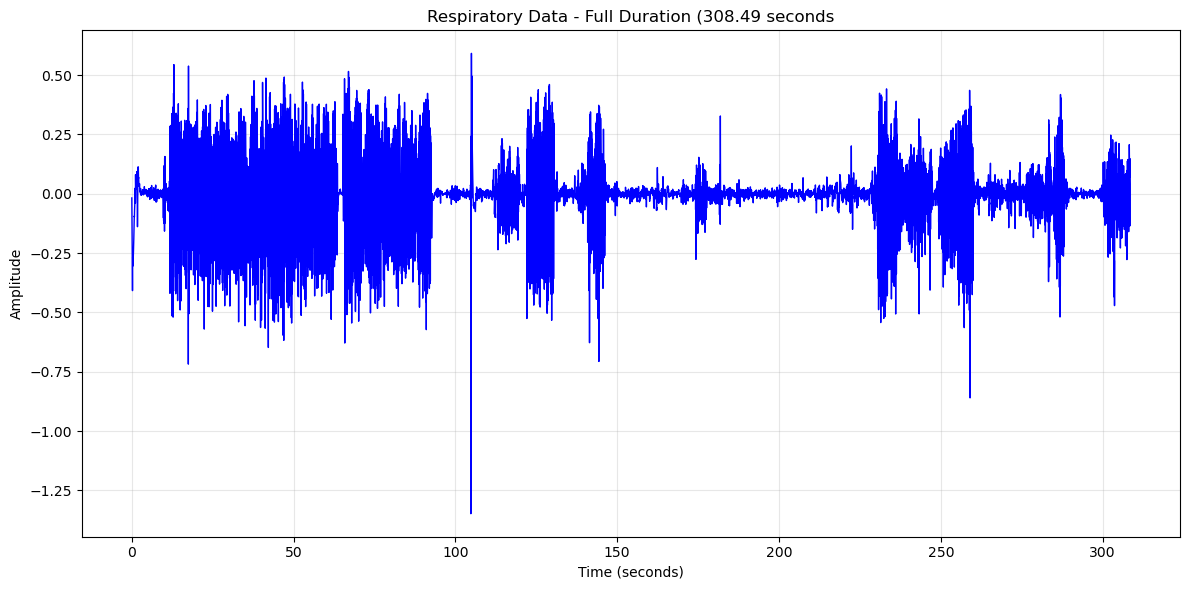

In [9]:
n_samples = len(rsp_cleaned)

# Create time array for x-axis
time = np.arange(n_samples) / fs + start_time

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(time, rsp_cleaned, 'b-', linewidth=1) 

# Add labels and title
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Respiratory Data - Full Duration ({n_samples/fs:.2f} seconds')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Plotting First 10 Seconds

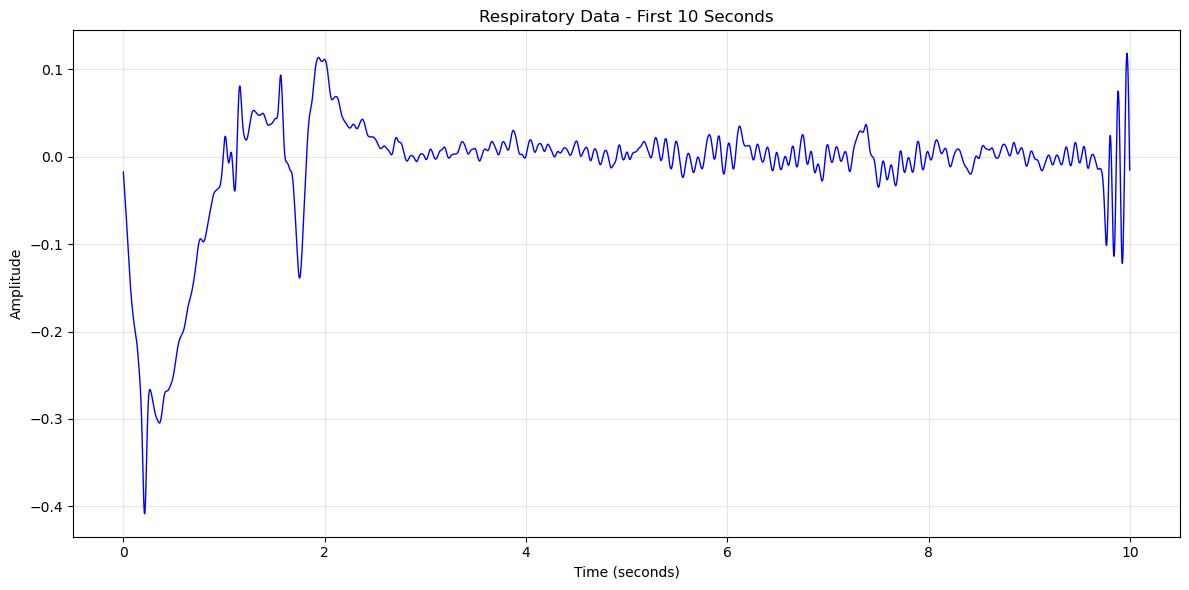

In [10]:
n_samples = int(10 * fs)

# Create time array for x-axis
time = np.arange(n_samples) / fs + start_time

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(time, rsp_cleaned[:n_samples], 'b-', linewidth=1)

# Add labels and title
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Respiratory Data - First {10} Seconds')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Plotting second by second using a custom resp_plotting function

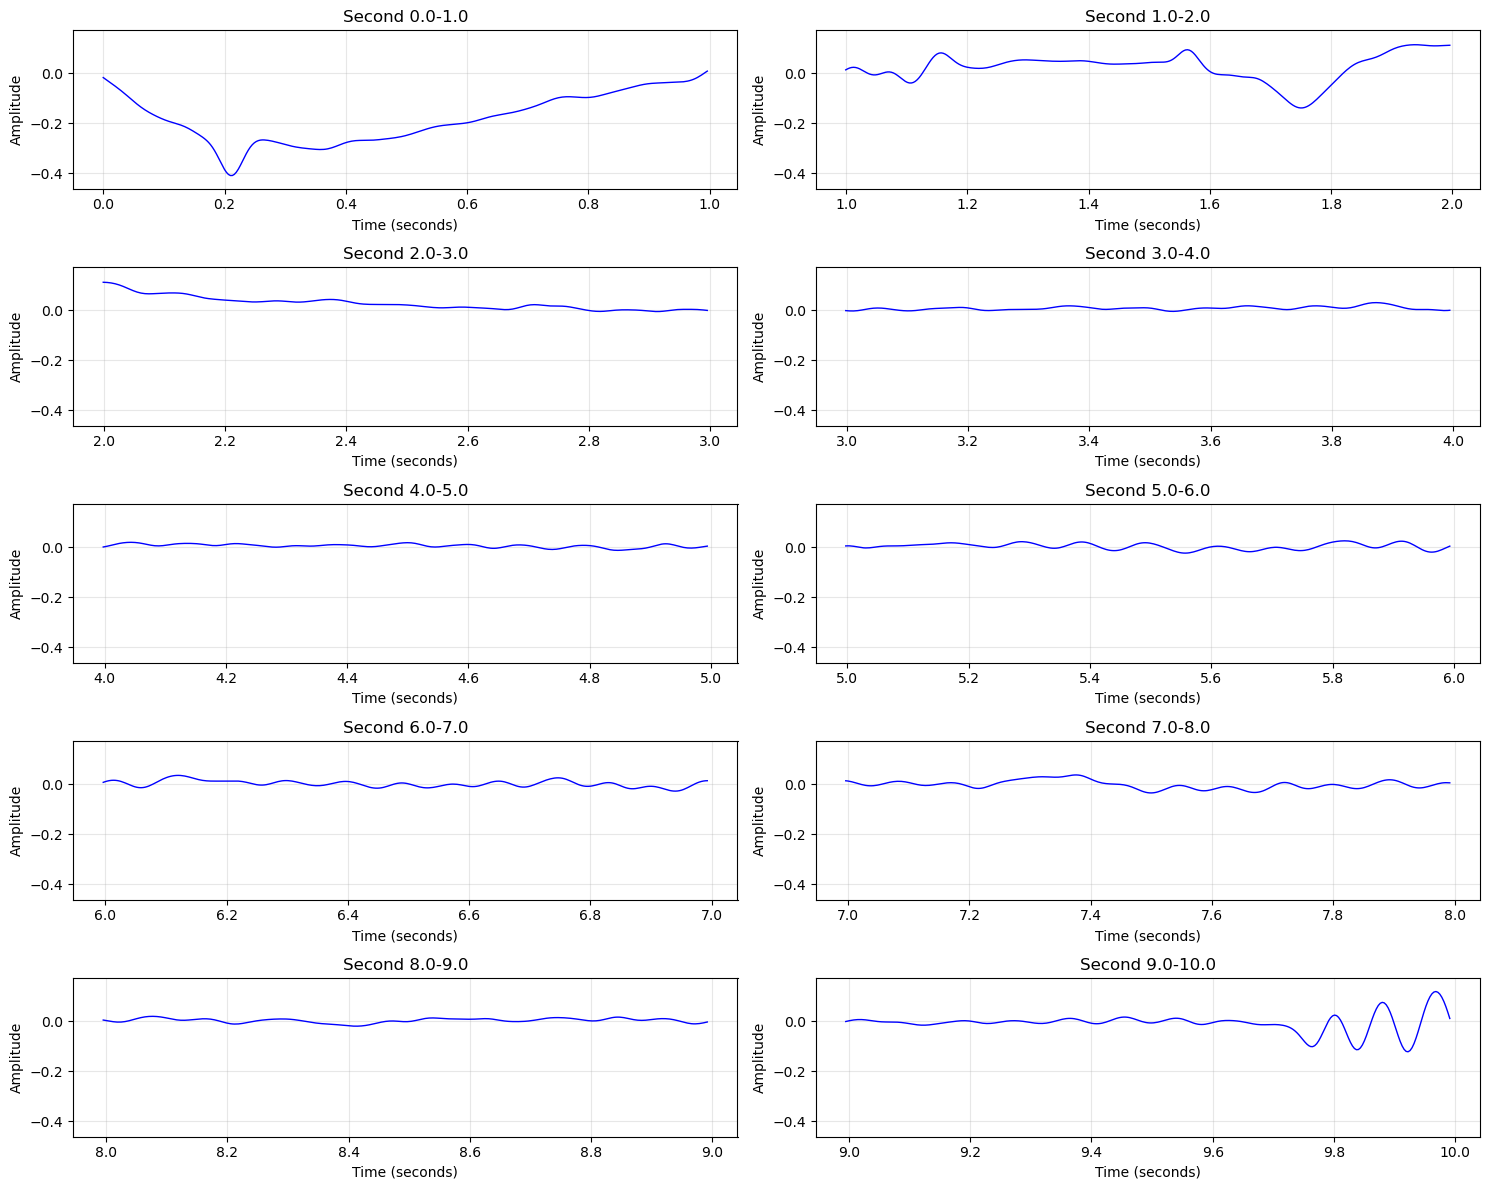

In [11]:
import resp_plotting
import importlib
importlib.reload(resp_plotting)

resp_plotting.plot_respiratory_data_by_second(rsp_cleaned, fs, start_time)


# Creating Dataframe with respiratory signal and fake Boris Data

In [12]:
# Generate timestamps
timestamps = np.arange(0, total_duration, 1/fs)  # Create time axis

# Create the respiration dataframe
resp_df = pd.DataFrame({
    "Timestamp (s)": timestamps,
    "Respiration Value": rsp_cleaned,
    "Behavioral Event": np.nan  # To be filled later from BORIS mapping
})


resp_df.head()

,Timestamp (s),Respiration Value,Behavioral Event
0,0.000000,-0.017617,NaN
1,0.003277,-0.023248,NaN
2,0.006554,-0.028882,NaN
3,0.009830,-0.034538,NaN
4,0.013107,-0.040235,NaN


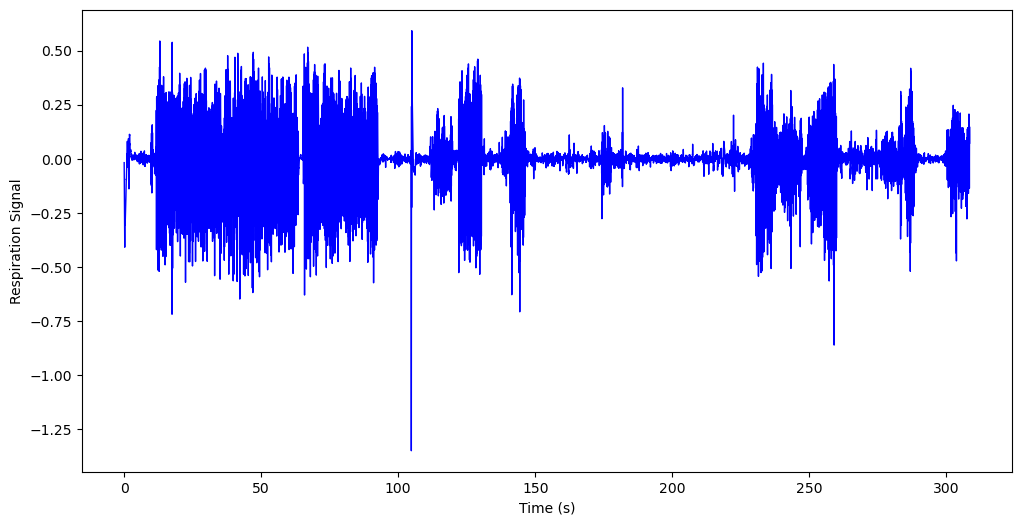

In [13]:
# Plot data
plt.figure(figsize=(12, 6))
plt.plot(resp_df["Timestamp (s)"], resp_df["Respiration Value"], 'b-', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.show()

Loading in fake bad boris data

In [14]:
boris_path = r"C:\Users\sjs93\Downloads\subject_11_cagemate_AE.csv"

boris_data = pd.read_csv(boris_path)
boris_data.head()

,Observation id,Observation date,Description,Media file,Total length,FPS,Subject,Behavior,Behavioral category,Modifiers,Behavior type,Start (s),Stop (s),Duration (s),Comment start,Comment stop
0,subject_11_cagemate,2025-03-02 18:31:11,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,308.6,10.0,subject,anogenital sniffing,NaN,NaN,STATE,9.880,13.605,3.725,NaN,NaN
1,subject_11_cagemate,2025-03-02 18:31:11,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,308.6,10.0,subject,chasing,NaN,NaN,STATE,13.803,15.855,2.052,NaN,NaN
2,subject_11_cagemate,2025-03-02 18:31:11,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,308.6,10.0,subject,anogenital sniffing,NaN,NaN,STATE,25.380,27.201,1.821,NaN,NaN
3,subject_11_cagemate,2025-03-02 18:31:11,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,308.6,10.0,subject,anogenital sniffing,NaN,NaN,STATE,31.454,33.055,1.601,NaN,NaN


In [15]:
boris_data = boris_data[['Behavior', 'Start (s)', 'Stop (s)']]
boris_data.head()

,Behavior,Start (s),Stop (s)
0,anogenital sniffing,9.880,13.605
1,chasing,13.803,15.855
2,anogenital sniffing,25.380,27.201
3,anogenital sniffing,31.454,33.055


Mapping behavior events to empty behavior column in the dataframe

In [16]:
# Iterate over BORIS events and map behaviors onto respiration timestamps
for _, row in boris_data.iterrows():
    start_time = row["Start (s)"]
    stop_time = row["Stop (s)"]
    behavior = row["Behavior"]

    # Mask: Find respiration timestamps that fall within the behavior window
    mask = (resp_df["Timestamp (s)"] >= start_time) & (resp_df["Timestamp (s)"] <= stop_time)

    # Assign the behavior to matching respiration timestamps
    resp_df.loc[mask, "Behavioral Event"] = behavior

C:\Users\sjs93\AppData\Local\Temp\ipykernel_15100\1375016238.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'anogenital sniffing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  resp_df.loc[mask, "Behavioral Event"] = behavior


In [17]:
start_time = 0

In [18]:
# Around when behavior first starts in fake dataset
resp_df[(resp_df["Timestamp (s)"] >= 3.84)].head(10)

,Timestamp (s),Respiration Value,Behavioral Event
1172,3.840410,0.014889,NaN
1173,3.843686,0.017120,NaN
1174,3.846963,0.019429,NaN
1175,3.850240,0.021711,NaN
1176,3.853517,0.023857,NaN
1177,3.856794,0.025770,NaN
1178,3.860070,0.027372,NaN
1179,3.863347,0.028607,NaN
1180,3.866624,0.029450,NaN
1181,3.869901,0.029903,NaN


# Plotting 20 seconds of Respiratory data with behavior plotted using resp_plotting 

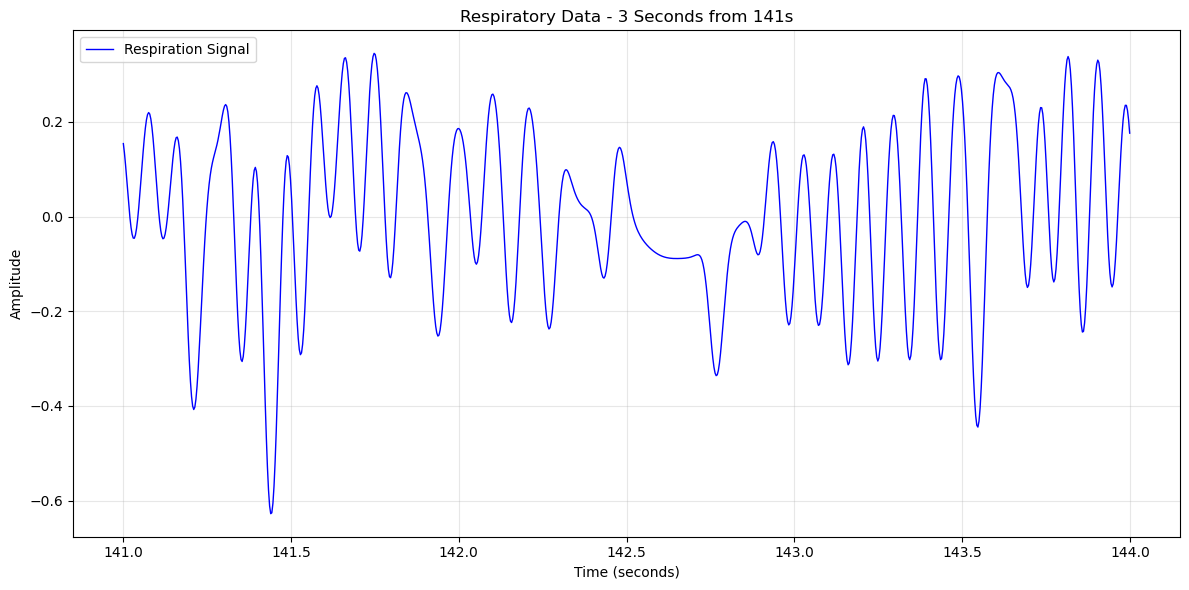

In [40]:
resp_plotting.resp_behavior_plot(resp_df, fs, start_time=141, duration=3)

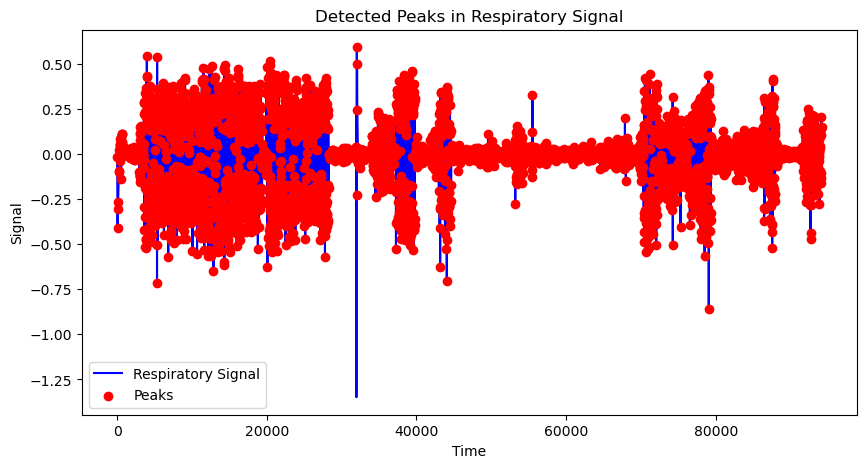

In [20]:
import signal_processing

peak_inds, peak_mags = signal_processing.peakfinder(resp_df['Respiration Value'])

# Create a new column in the DataFrame to mark detected peaks
resp_df['peak'] = 0
resp_df.loc[peak_inds.astype(int), 'peak'] = 1  # Mark peaks in the DataFrame

# Plot the signal with peaks
plt.figure(figsize=(10, 5))
plt.plot(resp_df.index, resp_df['Respiration Value'], label='Respiratory Signal', color='blue')
plt.scatter(resp_df.index[peak_inds.astype(int)], peak_mags, color='red', label='Peaks', zorder=3)
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Detected Peaks in Respiratory Signal')
plt.legend()
plt.show()

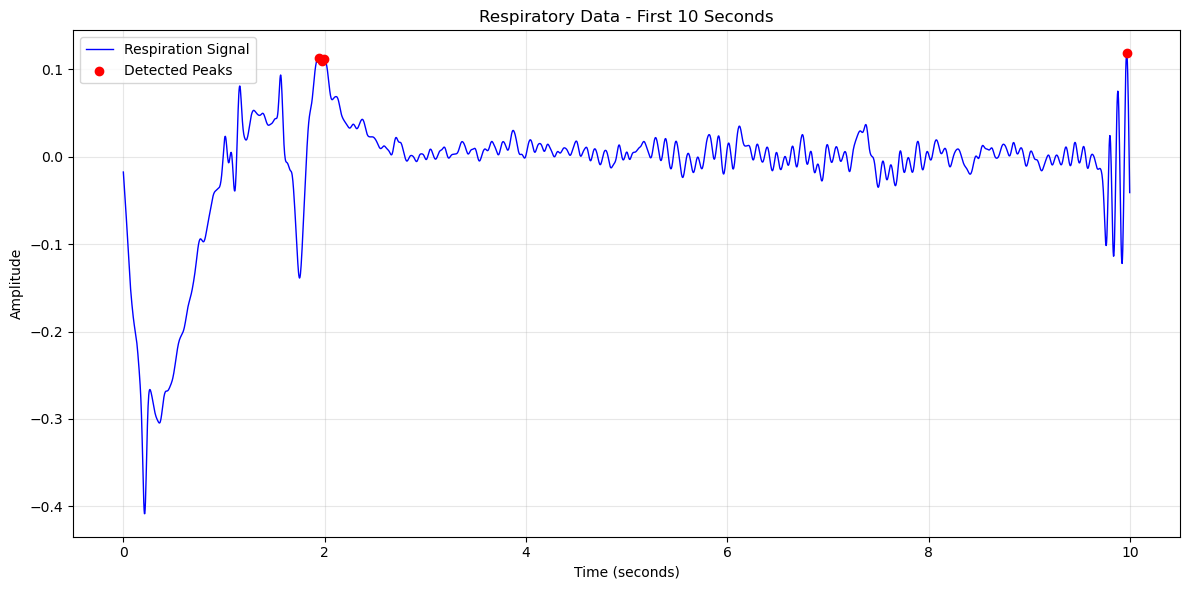

In [26]:
import importlib
importlib.reload(resp_plotting)

resp_plotting.final_resp_plot(resp_df, fs, start_time, duration=10, show_peaks=True, peak_sel=0.001, peak_thresh=0.1)

# Processing and Plotting High Frequency Areas in the Resp Data

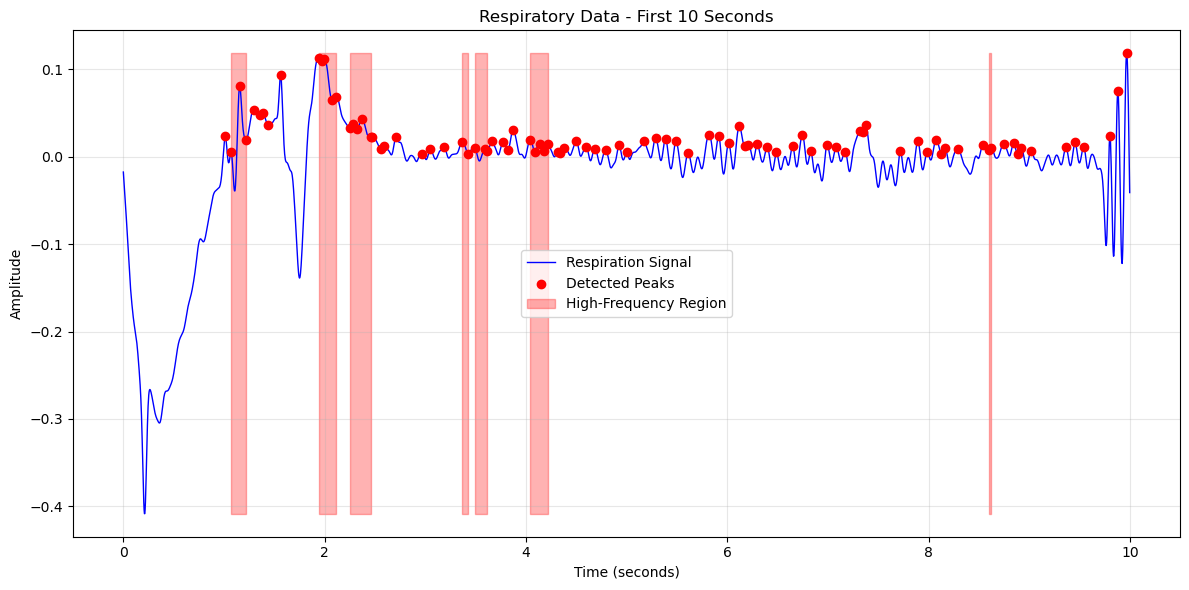

High-Frequency Regions (start, end): [(1.0125312, 1.0452991999999999), (2.2478848, 2.2839296), (3.7748736, 3.9550975999999998), (4.1353216, 4.3155456), (6.1800448, 6.209536), (6.3504384, 6.897664), (6.992691199999999, 7.0385664), (7.500595199999999, 7.759462399999999), (7.7987839999999995, 7.8381056), (7.9429631999999994, 7.9855616), (8.4115456, 8.4934656), (8.804761599999999, 8.8440832), (9.191424, 9.2274688), (9.315942399999999, 9.453567999999999), (9.4994432, 9.5387648), (9.5813632, 9.9221504), (10.1482496, 10.371072), (11.0198784, 11.213209599999999), (13.3070848, 13.5593984), (14.0181504, 14.195097599999999), (15.4959872, 15.879372799999999), (16.1185792, 16.4626432), (17.0164224, 17.232691199999998), (17.7143808, 17.8126848), (18.549964799999998, 18.969395199999997), (19.0185472, 19.3626112), (19.8148096, 20.073676799999998), (21.151744, 21.328691199999998), (21.6563712, 21.816934399999997), (21.8660864, 22.085632), (22.4395264, 22.695116799999997), (23.248896, 23.330816), (23.37

In [29]:
importlib.reload(signal_processing)
importlib.reload(resp_plotting)

high_freq_regions = signal_processing.find_high_frequency_regions(resp_df, fs, window_size=5,threshold_percentile=25)

resp_plotting.final_resp_plot2(resp_df, fs, start_time, duration=10, show_peaks=True, peak_sel=0.001, peak_thresh=0.003, show_high_freq_regions=True, high_freq_threshold_percentile=20)

print("High-Frequency Regions (start, end):", high_freq_regions)